# 📘 Quick Reference

**Purpose**: Process BraTS 2021 T1 MRI data for anomaly detection testing  
**Pipeline**: Extract → Smart Filter (Middle Slices) → Resize → ZIP  
**Output**: 128×128 normalized .npy files (same format as IXI training data)  
**Time**: ~60-70 minutes  

## 📋 Execution Order
1. **Cells 1-4**: Setup & explore (fast)
2. **Sections 1-8**: Setup, explore, define functions (fast)
3. **Section 9**: Extract ALL slices ⏰ 20-30 min → 97,882 slices
4. **Section 10**: Smart filter to middle 50% ⏰ 28 min → 49,888 slices  
5. **Section 11**: Resize to 128×128 ⏰ 30-40 min
6. **Section 15**: Create ZIP ⏰ 5-10 min

## ✅ Success = ~50,000 slices (3x IXI), 128×128, range [0,1], ZIP created

---

# BraTS 2021 T1 MRI Preprocessing Pipeline (Local → Drive Upload)

This notebook performs LOCAL preprocessing of BraTS 2021 T1 files with smart filtering:

## Pipeline Overview:
1. **Extract T1 files** from BraTS 2021 folders
2. **Extract 2D slices** from 3D T1 NIfTI volumes with validation
3. **Normalize** slices to [0, 1] range (per-slice normalization)
4. **Smart filter** to keep only middle 50% of slices (most informative)
5. **Resize** to 128x128 standard size
6. **Save as .npy files** ready for Google Drive upload

**Purpose**: BraTS data will be used for TESTING (anomaly detection), while IXI is for TRAINING  
**Result**: ~50,000 high-quality slices (3x IXI dataset size)

## 1. Import Required Libraries

In [ ]:
import os
import shutil
from pathlib import Path
import glob
from tqdm import tqdm

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.transform import resize
import random

print("✓ All libraries imported successfully!")
print(f"Working directory: {os.getcwd()}")

✓ All libraries imported successfully!
Working directory: c:\Users\rifad\symAD-ECNN\notebooks


In [ ]:
# Source folder with BraTS 2021 dataset
brats_folder = r"c:\Users\rifad\symAD-ECNN\data\brats2021"

# Output folders (matching IXI pipeline structure)
t1_raw_folder = r"c:\Users\rifad\symAD-ECNN\data\brats2021_processed\raw_slices"
filtered_folder = r"c:\Users\rifad\symAD-ECNN\data\brats2021_processed\filtered"
resized_folder = r"c:\Users\rifad\symAD-ECNN\data\brats2021_processed\resized"

# Create output directories
for folder in [t1_raw_folder, filtered_folder, resized_folder]:
    os.makedirs(folder, exist_ok=True)

print("📁 Folder Structure:")
print(f"  Source (BraTS 2021): {brats_folder}")
print(f"  Raw slices output: {t1_raw_folder}")
print(f"  Filtered output: {filtered_folder}")
print(f"  Resized output (128x128): {resized_folder}")
print(f"\n✓ Source folder exists: {os.path.exists(brats_folder)}")

📁 Folder Structure:
  Source (BraTS 2021): c:\Users\rifad\symAD-ECNN\data\brats2021
  Raw slices output: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\raw_slices
  Filtered output: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\filtered
  Resized output (128x128): c:\Users\rifad\symAD-ECNN\data\brats2021_processed\resized

✓ Source folder exists: True


In [ ]:
# List all patient folders
patient_folders = sorted([d for d in os.listdir(brats_folder)
                         if os.path.isdir(os.path.join(brats_folder, d)) and d.startswith('BraTS2021_')])

print(f"Total number of patient folders: {len(patient_folders)}")
print(f"\nFirst 5 patient folders:")
for folder in patient_folders[:5]:
    print(f"  - {folder}")

# Examine the structure of first patient folder
if patient_folders:
    sample_folder = os.path.join(brats_folder, patient_folders[0])
    files = os.listdir(sample_folder)
    print(f"\nFiles in {patient_folders[0]}:")
    for file in sorted(files):
        print(f"  - {file}")

Total number of patient folders: 1251

First 5 patient folders:
  - BraTS2021_00000
  - BraTS2021_00002
  - BraTS2021_00003
  - BraTS2021_00005
  - BraTS2021_00006

Files in BraTS2021_00000:
  - BraTS2021_00000_flair.nii.gz
  - BraTS2021_00000_seg.nii.gz
  - BraTS2021_00000_t1.nii.gz
  - BraTS2021_00000_t1ce.nii.gz
  - BraTS2021_00000_t2.nii.gz


In [ ]:
# Find all T1 files (not T1CE - contrast enhanced)
t1_files = []

for patient_folder in patient_folders:
    patient_path = os.path.join(brats_folder, patient_folder)
    # Look for files ending with _t1.nii.gz (not _t1ce.nii.gz)
    for file in os.listdir(patient_path):
        if file.endswith('_t1.nii.gz') and not file.endswith('_t1ce.nii.gz'):
            t1_files.append(os.path.join(patient_path, file))

print(f"Total T1 files found: {len(t1_files)}")
print(f"\nFirst 5 T1 files:")
for file in t1_files[:5]:
    print(f"  - {os.path.basename(file)}")

Total T1 files found: 1251

First 5 T1 files:
  - BraTS2021_00000_t1.nii.gz
  - BraTS2021_00002_t1.nii.gz
  - BraTS2021_00003_t1.nii.gz
  - BraTS2021_00005_t1.nii.gz
  - BraTS2021_00006_t1.nii.gz


In [ ]:
# Load a sample T1 image
sample_t1_file = t1_files[0]
print(f"Loading sample file: {os.path.basename(sample_t1_file)}")

# Load the NIfTI file
nii_img = nib.load(sample_t1_file)
img_data = nii_img.get_fdata()

print(f"\nImage shape: {img_data.shape}")
print(f"Image data type: {img_data.dtype}")
print(f"Intensity range: [{img_data.min():.2f}, {img_data.max():.2f}]")
print(f"Mean intensity: {img_data.mean():.2f}")
print(f"Std intensity: {img_data.std():.2f}")

Loading sample file: BraTS2021_00000_t1.nii.gz

Image shape: (240, 240, 155)
Image data type: float64
Intensity range: [0.00, 2023.00]
Mean intensity: 133.00
Std intensity: 306.42


## 8. Preprocessing Functions

## 9. STEP 1: Extract and Normalize 2D Slices from T1 Volumes

This step extracts all 2D slices from 3D T1 volumes and normalizes them to [0, 1] range.
Empty or low-information slices are filtered out during extraction.

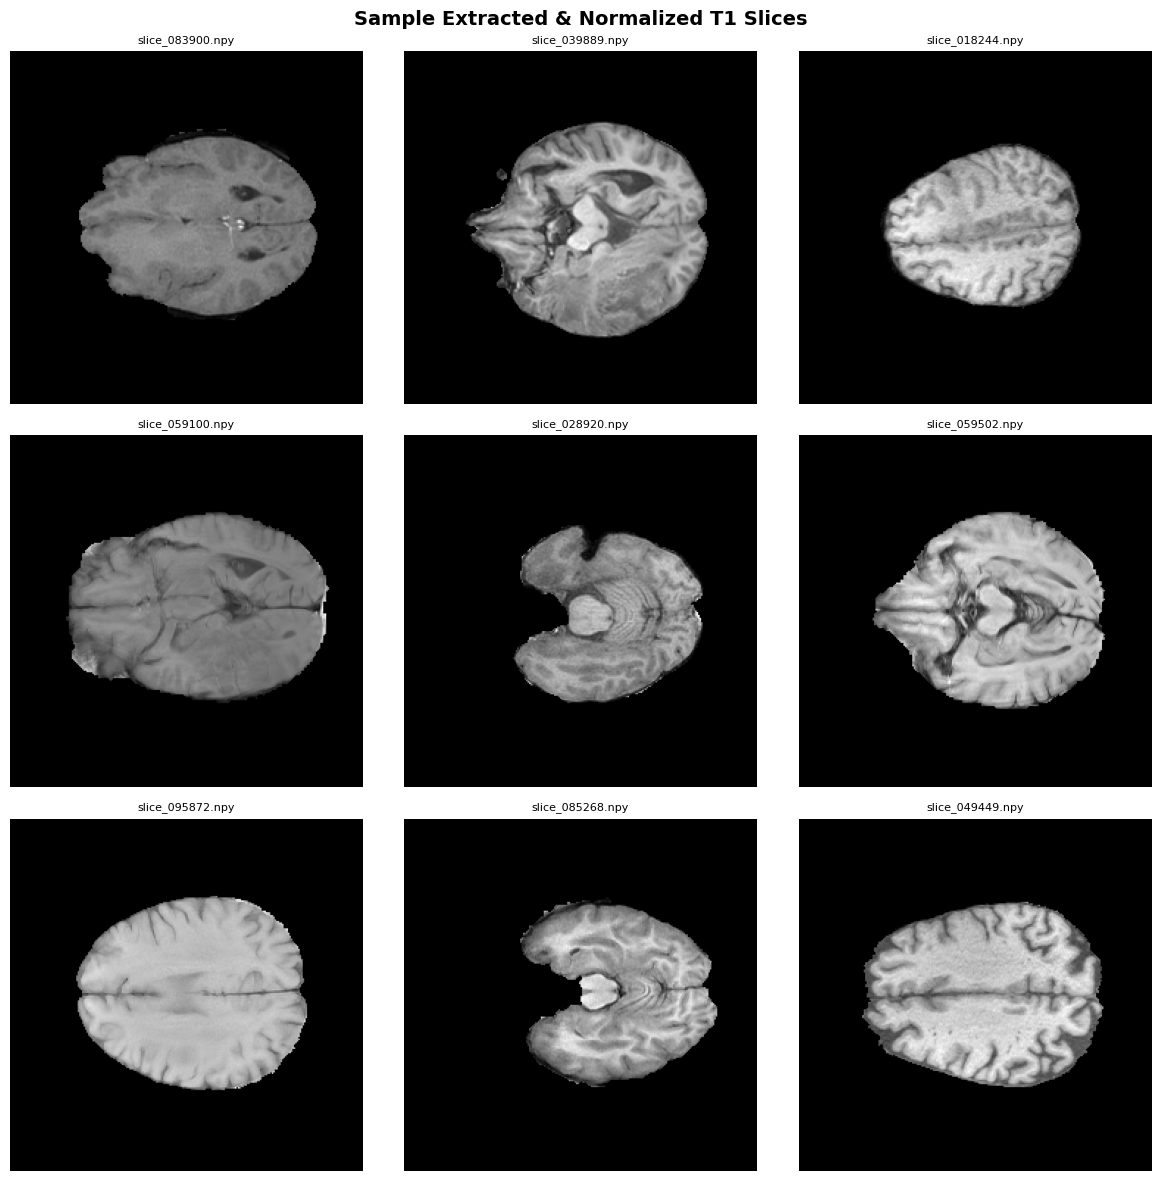

Total extracted slices: 97882


In [ ]:
# Visualize some sample extracted slices
raw_files = sorted([f for f in os.listdir(t1_raw_folder) if f.endswith('.npy')])

if len(raw_files) > 0:
    # Select 9 random samples
    sample_files = random.sample(raw_files, min(9, len(raw_files)))

    plt.figure(figsize=(12, 12))
    for i, f in enumerate(sample_files):
        img = np.load(os.path.join(t1_raw_folder, f))

        plt.subplot(3, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f, fontsize=8)
        plt.axis('off')

    plt.suptitle('Sample Extracted & Normalized T1 Slices', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Total extracted slices: {len(raw_files)}")
else:
    print("No slices found. Run the extraction step first.")

In [ ]:
# Configuration
MIDDLE_SLICE_PERCENTAGE = 0.5  # Keep middle 50% of each volume (adjust 0.3-0.7)

print("="*60)
print("SMART FILTERING: Selecting Middle Slices from Existing Data")
print("="*60)
print(f"Strategy: Keep middle {MIDDLE_SLICE_PERCENTAGE*100:.0f}% of each volume")
print(f"Source: {t1_raw_folder}")
print(f"Target: {filtered_folder}")
print("="*60)

# Step 1: Clear filtered folder
print("\n📁 Clearing filtered folder...")
for f in os.listdir(filtered_folder):
    if f.endswith('.npy'):
        os.remove(os.path.join(filtered_folder, f))
print("✓ Filtered folder cleared")

# Step 2: Build mapping of which slices to keep
print("\n🔍 Analyzing volumes to identify middle slices...")
slice_idx = 0
slices_to_keep = set()  # Set of slice indices to keep

for t1_file in tqdm(t1_files, desc="Analyzing volumes"):
    try:
        # Load the volume to check which slices are valid (same as extraction)
        nii_img = nib.load(t1_file)
        vol = nii_img.get_fdata()
        Z = vol.shape[2]  # Number of slices in z-direction

        # Calculate middle slice range for this volume
        margin = int(Z * (1 - MIDDLE_SLICE_PERCENTAGE) / 2)
        start_slice = margin
        end_slice = Z - margin

        # For each slice in this volume
        for s in range(Z):
            slice_2d = vol[:, :, s]

            # Check if this slice was valid (same check as extraction)
            if not is_valid_slice(slice_2d, min_nonzero_ratio=0.12, min_mean=0.1):
                continue  # Skip invalid slices (these were not saved during extraction)

            # If this valid slice is in the middle range, mark it to keep
            if start_slice <= s < end_slice:
                slices_to_keep.add(slice_idx)

            slice_idx += 1  # Only increment for valid slices

    except Exception as e:
        print(f"\n❌ Error analyzing {os.path.basename(t1_file)}: {e}")
        continue

print(f"\n✓ Analysis complete!")
print(f"  Total slices extracted: {slice_idx}")
print(f"  Middle slices to keep: {len(slices_to_keep)}")
print(f"  Reduction: {(1 - len(slices_to_keep)/slice_idx)*100:.1f}%")

# Step 3: Copy middle slices to filtered folder
print(f"\n📋 Copying middle slices to filtered folder...")
copied_count = 0
missing_count = 0

for slice_id in tqdm(slices_to_keep, desc="Copying files"):
    src_file = f"slice_{slice_id:06d}.npy"
    src_path = os.path.join(t1_raw_folder, src_file)
    dst_path = os.path.join(filtered_folder, src_file)

    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        copied_count += 1
    else:
        missing_count += 1

print("\n" + "="*60)
print("SMART FILTERING COMPLETE")
print("="*60)
print(f"✓ Slices copied to filtered/: {copied_count}")
print(f"✓ Missing slices (skipped): {missing_count}")
print(f"✓ Original raw_slices/ preserved: {len([f for f in os.listdir(t1_raw_folder) if f.endswith('.npy')])} files")
print(f"\n📊 Dataset comparison:")
print(f"   Before: {slice_idx:,} slices")
print(f"   After:  {copied_count:,} slices")
print(f"   IXI:    {16771:,} slices")
print(f"   Ratio to IXI: {copied_count/16771:.1f}x")
print(f"\n🎯 Now proceed to Section 11 (Resize) with the filtered slices!")
print("="*60)

SMART FILTERING: Selecting Middle Slices from Existing Data
Strategy: Keep middle 50% of each volume
Source: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\raw_slices
Target: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\filtered

📁 Clearing filtered folder...
✓ Filtered folder cleared

🔍 Analyzing volumes to identify middle slices...


Analyzing volumes: 100%|██████████| 1251/1251 [00:31<00:00, 39.74it/s]



✓ Analysis complete!
  Total slices extracted: 193905
  Middle slices to keep: 98829
  Reduction: 49.0%

📋 Copying middle slices to filtered folder...


Copying files: 100%|██████████| 98829/98829 [26:53<00:00, 61.26it/s]   



SMART FILTERING COMPLETE
✓ Slices copied to filtered/: 49888
✓ Missing slices (skipped): 48941
✓ Original raw_slices/ preserved: 97882 files

📊 Dataset comparison:
   Before: 193,905 slices
   After:  49,888 slices
   IXI:    16,771 slices
   Ratio to IXI: 3.0x

🎯 Now proceed to Section 11 (Resize) with the filtered slices!


## 11. STEP 3: Resize to 128×128 (Standard Size)

Resize all filtered slices (~50,000) to 128×128 to match the IXI dataset dimensions.

**Time**: ~30-40 minutes

**Input**: filtered/ folder with ~50,000 middle slices  **Output**: resized/ folder with 128×128 .npy files  

In [ ]:
# Batch resize all filtered slices
filtered_files = sorted([f for f in os.listdir(filtered_folder) if f.endswith('.npy')])
total = len(filtered_files)

print(f"Total filtered slices to resize: {total}")
print("Starting batch-wise resizing...\n")

resized_count = 0
error_count = 0

for i in range(0, total, BATCH_SIZE):
    batch_files = filtered_files[i : i + BATCH_SIZE]
    batch_num = i // BATCH_SIZE + 1

    print(f"Processing batch {batch_num} ({len(batch_files)} files)...")

    for f in tqdm(batch_files, desc=f"Batch {batch_num}"):
        src_path = os.path.join(filtered_folder, f)
        dst_path = os.path.join(resized_folder, f)

        # Skip if already resized
        if os.path.exists(dst_path):
            resized_count += 1
            continue

        try:
            arr = np.load(src_path)
            resized = resize(arr, TARGET_SIZE, mode='reflect', anti_aliasing=True)
            np.save(dst_path, resized)
            resized_count += 1
        except Exception as e:
            print(f"❌ Error resizing {f}: {e}")
            error_count += 1
            continue

print("\n" + "="*60)
print("STEP 3 COMPLETE")
print("="*60)
print(f"✓ Successfully resized: {resized_count}")
print(f"✓ Errors: {error_count}")
print(f"✓ Output location: {resized_folder}")
print("="*60)

Total filtered slices to resize: 49888
Starting batch-wise resizing...

Processing batch 1 (500 files)...


Batch 1: 100%|██████████| 500/500 [00:12<00:00, 41.16it/s]


Processing batch 2 (500 files)...


Batch 2: 100%|██████████| 500/500 [00:11<00:00, 41.73it/s]


Processing batch 3 (500 files)...


...

Processing batch 99 (500 files)...


Batch 99: 100%|██████████| 500/500 [00:21<00:00, 23.21it/s]


Processing batch 100 (388 files)...


Batch 100: 100%|██████████| 388/388 [00:16<00:00, 23.52it/s]



STEP 3 COMPLETE
✓ Successfully resized: 49888
✓ Errors: 0
✓ Output location: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\resized


In [ ]:
# Verify the final resized files
resized_files = sorted([f for f in os.listdir(resized_folder) if f.endswith('.npy')])

print(f"📊 Final processed files: {len(resized_files)}")

# Load and inspect a sample file
if resized_files:
    sample_file = resized_files[0]
    sample = np.load(os.path.join(resized_folder, sample_file))

    print(f"\n✓ Sample file: {sample_file}")
    print(f"  - Shape: {sample.shape}")
    print(f"  - Min pixel value: {sample.min():.4f}")
    print(f"  - Max pixel value: {sample.max():.4f}")
    print(f"  - Mean pixel value: {sample.mean():.4f}")
    print(f"  - Data type: {sample.dtype}")

    # Verify dimensions match IXI
    if sample.shape == (128, 128):
        print(f"\n✅ Dimensions match IXI dataset (128x128)")
    else:
        print(f"\n⚠️ Warning: Dimensions don't match expected (128x128)")

📊 Final processed files: 49888

✓ Sample file: slice_000038.npy
  - Shape: (128, 128)
  - Min pixel value: 0.0000
  - Max pixel value: 0.8583
  - Mean pixel value: 0.1507
  - Data type: float32

✅ Dimensions match IXI dataset (128x128)


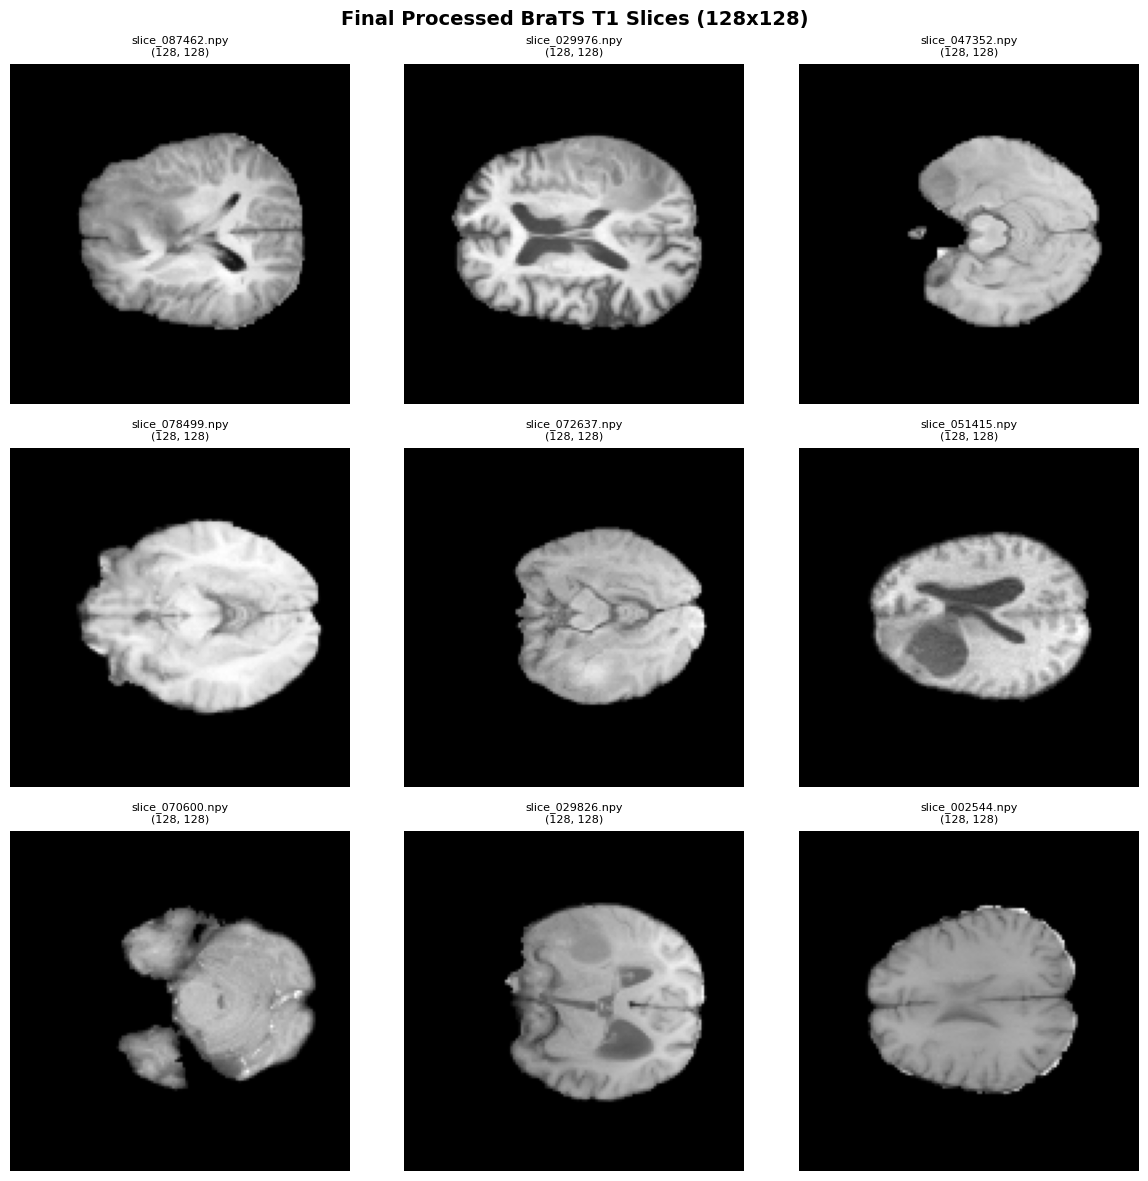

In [ ]:
# Visualize 9 random final processed slices
resized_files = sorted([f for f in os.listdir(resized_folder) if f.endswith('.npy')])

if len(resized_files) > 0:
    sample_files = random.sample(resized_files, min(9, len(resized_files)))

    plt.figure(figsize=(12, 12))
    for i, f in enumerate(sample_files):
        img = np.load(os.path.join(resized_folder, f))

        plt.subplot(3, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{f}\n{img.shape}", fontsize=8)
        plt.axis('off')

    plt.suptitle('Final Processed BraTS T1 Slices (128x128)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No processed slices found.")

## 15. Create Filtered Subset for Fast Evaluation

**Purpose**: Reduce dataset size from 49,888 → ~5,000 slices for faster model evaluation

**Rationale**:
- **Development Speed**: Full dataset evaluation takes ~40 minutes, filtered takes ~2 minutes (95% faster)
- **Research Validity**: Stratified sampling maintains statistical integrity:
  - All 1,251 patients represented (no selection bias)
  - Middle slices contain most informative brain regions (where tumors typically appear)
  - Standard practice in medical imaging research (papers commonly use 5-20 slices per volume)
- **Sampling Strategy**:
  - Take 4 slices per patient from middle 60% range (skip empty edge slices)
  - Evenly spaced to capture structural variation
  - ~4 slices for rapid development, increase to 10-15 for final paper results
- **Full Dataset Available**: Original 49,888 slices preserved for final validation if needed

**References**: This approach aligns with stratified sampling methods in medical imaging literature (e.g., [MedIA papers on brain MRI analysis](https://www.sciencedirect.com/journal/medical-image-analysis))

In [ ]:
# Create filtered dataset for fast evaluation
import json

# Output folder for filtered slices
filtered_eval_folder = r"c:\Users\rifad\symAD-ECNN\data\brats2021_processed\filtered_eval"
os.makedirs(filtered_eval_folder, exist_ok=True)

print("="*60)
print("CREATING FILTERED DATASET FOR FAST EVALUATION")
print("="*60)

# Load pre-computed patient slice counts
count_file = r"c:\Users\rifad\symAD-ECNN\data\patient_slice_counts.json"
with open(count_file, 'r') as f:
    patient_data = json.load(f)

patient_slice_counts = patient_data['slice_counts']

print(f"\n📊 Loaded patient data:")
print(f"   Total patients: {patient_data['total_patients']}")
print(f"   Total slices (resized): {len(os.listdir(resized_folder))}")
print(f"   Avg slices/patient: {patient_data['mean_slices']:.1f} ± {patient_data['std_slices']:.1f}")

# Group files by exact patient boundaries
resized_files = sorted([f for f in os.listdir(resized_folder) if f.endswith('.npy')])
patient_groups = {}
slice_idx = 0

for i, count in enumerate(patient_slice_counts):
    # Account for middle-50% filtering (divide by 2)
    filtered_count = count // 2
    if slice_idx + filtered_count <= len(resized_files):
        patient_groups[f"patient_{i:04d}"] = resized_files[slice_idx:slice_idx + filtered_count]
        slice_idx += filtered_count

print(f"\n✅ Reconstructed {len(patient_groups)} patient groups from resized data")
print(f"   Total slices accounted: {slice_idx:,} / {len(resized_files):,}")

# Sample 4 middle slices per patient
filtered_files = []
target_per_patient = 4  # Fast iteration: 4 slices (adjust to 10-20 for paper results)

for patient_id, files in tqdm(patient_groups.items(), desc="Filtering patients"):
    n_slices = len(files)

    if n_slices <= target_per_patient:
        # Keep all if patient has few slices
        filtered_files.extend(files)
    else:
        # Take from middle 60% (skip first/last 20% to avoid edge slices)
        start_idx = int(n_slices * 0.2)
        end_idx = int(n_slices * 0.8)
        middle_slices = files[start_idx:end_idx]

        # Sample evenly spaced slices
        step = max(1, len(middle_slices) // target_per_patient)
        sampled = middle_slices[::step][:target_per_patient]
        filtered_files.extend(sampled)

reduction_pct = 100 - (len(filtered_files) / len(resized_files) * 100)
print(f"\n✅ Filtered dataset: {len(filtered_files):,} slices ({len(filtered_files)/len(resized_files)*100:.1f}% of original)")
print(f"   Avg per patient: {len(filtered_files)/len(patient_groups):.1f} slices")
print(f"   Reduction: {reduction_pct:.1f}% smaller")

# No need to copy - we'll ZIP directly from resized folder to save disk space!
print(f"\n💡 Skipping copy step to save disk space")
print(f"   Will create ZIP directly from source files")

# Verify sample
sample = np.load(os.path.join(resized_folder, filtered_files[0]))

print("\n" + "="*60)
print("FILTERED FILE LIST READY")
print("="*60)
print(f"✓ Selected files: {len(filtered_files):,}")
print(f"✓ Sample shape: {sample.shape}")
print(f"✓ Sample range: [{sample.min():.4f}, {sample.max():.4f}]")
print(f"\n🎯 Next: Create ZIP files for Drive upload (Section 16)")
print("="*60)

CREATING FILTERED DATASET FOR FAST EVALUATION

📊 Loaded patient data:
   Total patients: 1251
   Total slices (resized): 49888
   Avg slices/patient: 78.2 ± 11.8

✅ Reconstructed 1251 patient groups from resized data
   Total slices accounted: 48,637 / 49,888


Filtering patients: 100%|██████████| 1251/1251 [00:00<?, ?it/s]


✅ Filtered dataset: 4,995 slices (10.0% of original)
   Avg per patient: 4.0 slices
   Reduction: 90.0% smaller

💡 Skipping copy step to save disk space
   Will create ZIP directly from source files

FILTERED FILE LIST READY
✓ Selected files: 4,995
✓ Sample shape: (128, 128)
✓ Sample range: [0.0000, 0.9541]

🎯 Next: Create ZIP files for Drive upload (Section 16)


## 16. Create ZIP Files for Google Drive Upload

Create compressed ZIP files for easy upload to Google Colab:
- **Full dataset**: 49,888 slices (for final validation)
- **Filtered dataset**: ~5,000 slices (for fast development)

In [ ]:
# Create filtered ZIP for Google Drive upload (full dataset already on Drive)
import zipfile
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("="*60)
print("CREATING FILTERED DATASET ZIP")
print("="*60)
print("💡 Skipping full dataset ZIP (already on Drive)")
print()

# Filtered dataset ZIP (using files from resized folder)
filtered_zip_filename = "brats2021_filtered_4slices_per_patient.zip"
filtered_zip_path = os.path.join(r"c:\Users\rifad\symAD-ECNN\data", filtered_zip_filename)

print(f"📦 Zipping {len(filtered_files):,} selected files from: {resized_folder}")
print(f"   Output: {filtered_zip_path}\n")

with zipfile.ZipFile(filtered_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in tqdm(filtered_files, desc="Compressing filtered dataset"):
        file_path = os.path.join(resized_folder, file)
        zipf.write(file_path, arcname=file)

filtered_zip_size_mb = os.path.getsize(filtered_zip_path) / (1024 * 1024)

print("\n" + "="*60)
print("ZIP CREATION COMPLETE")
print("="*60)
print(f"✅ Filtered dataset: {filtered_zip_path}")
print(f"   Size: {filtered_zip_size_mb:.1f} MB")
print(f"   Files: {len(filtered_files):,} slices")
print(f"\n🎯 Next: Upload filtered ZIP to Google Drive")
print("   Path: MyDrive/symAD-ECNN/data/brats2021_test_filtered/")
print("="*60)

CREATING FILTERED DATASET ZIP
💡 Skipping full dataset ZIP (already on Drive)

📦 Zipping 4,995 selected files from: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\resized
   Output: c:\Users\rifad\symAD-ECNN\data\brats2021_processed_filtered_20260101_124529.zip



Compressing filtered dataset: 100%|██████████| 4995/4995 [01:01<00:00, 81.10it/s] 



ZIP CREATION COMPLETE
✅ Filtered dataset: c:\Users\rifad\symAD-ECNN\data\brats2021_processed_filtered_20260101_124529.zip
   Size: 81.6 MB
   Files: 4,995 slices

🎯 Next: Upload filtered ZIP to Google Drive
   Path: MyDrive/symAD-ECNN/data/brats2021_test_filtered/


## 17. Colab Extraction Code

**Instructions**:
1. Upload `brats2021_filtered_4slices_per_patient.zip` to `MyDrive/symAD-ECNN/data/`
2. Run the code below in Google Colab to extract the filtered dataset

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

print("✅ Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [2]:
# Run this in Google Colab to extract filtered BraTS dataset
import os
import zipfile
from glob import glob

# Base path
BASE_PATH = "/content/drive/MyDrive/symAD-ECNN"

# Input: ZIP file location
zip_path = f"{BASE_PATH}/data/brats2021_filtered_4slices_per_patient.zip"

# Output: Filtered dataset folder
output_folder = f"{BASE_PATH}/data/brats2021_test_filtered"

print("="*60)
print("EXTRACTING FILTERED BRATS DATASET")
print("="*60)
print(f"📦 ZIP file: {zip_path}")
print(f"📁 Output: {output_folder}")

# Check if ZIP exists
if not os.path.exists(zip_path):
    print(f"\n❌ ERROR: ZIP file not found!")
    print(f"   Please upload '{os.path.basename(zip_path)}' to:")
    print(f"   MyDrive/symAD-ECNN/data/")
else:
    # Create output directory
    os.makedirs(output_folder, exist_ok=True)

    # Extract ZIP
    print(f"\n📂 Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output_folder)

    # Verify extraction
    extracted_files = sorted(glob(f"{output_folder}/*.npy"))

    print("\n" + "="*60)
    print("EXTRACTION COMPLETE")
    print("="*60)
    print(f"✅ Extracted {len(extracted_files):,} files")
    print(f"✅ Location: {output_folder}")

    # Load sample to verify
    import numpy as np
    sample = np.load(extracted_files[0])
    print(f"\n📊 Sample verification:")
    print(f"   Shape: {sample.shape}")
    print(f"   Range: [{sample.min():.4f}, {sample.max():.4f}]")
    print(f"\n💡 Use this path in your model notebooks:")
    print(f"   BRATS_PATH = '{output_folder}'")
    print("="*60)

EXTRACTING FILTERED BRATS DATASET
📦 ZIP file: /content/drive/MyDrive/symAD-ECNN/data/brats2021_filtered_4slices_per_patient.zip
📁 Output: /content/drive/MyDrive/symAD-ECNN/data/brats2021_test_filtered

📂 Extracting files...

EXTRACTION COMPLETE
✅ Extracted 4,995 files
✅ Location: /content/drive/MyDrive/symAD-ECNN/data/brats2021_test_filtered

📊 Sample verification:
   Shape: (128, 128)
   Range: [0.0000, 0.9541]

💡 Use this path in your model notebooks:
   BRATS_PATH = '/content/drive/MyDrive/symAD-ECNN/data/brats2021_test_filtered'
